In [12]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [5]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [21]:
print('타겟변수 :', data[15,0])
image = data[15, 1:].reshape(28,28)
image.shape

타겟변수 : 7.0


(28, 28)

In [22]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0115121162253253213  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 63107170251252252252252250214  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 25192226226241252253202252252252252252225  0  0  0  0  0  0
  0  0  0  0  0  0  0 68223252252252252252 39 19 39 65224252252183  0  0  0  0  0  0
  0  0  0  0  0  0  0186252252252245108 53  0  0  0150252252220 2

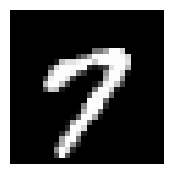

In [25]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [ ]:
%pip install opencv-python==4.8.1.78

In [35]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

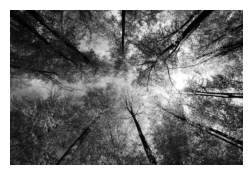

In [36]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [38]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [42]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [44]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


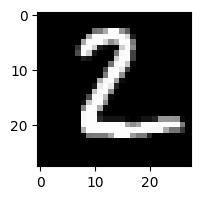

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [48]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [50]:
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [53]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [62]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [66]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [71]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

In [73]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성
# 3. 학습과정 설정

In [77]:
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_7 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [78]:
%%time
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 1s 28ms/step - loss: 2.3201 - accuracy: 0.1014 - val_loss: 2.2913 - val_accuracy: 0.1000
Epoch 2/200
7/7 [==============================] - 0s 4ms/step - loss: 2.2689 - accuracy: 0.1186 - val_loss: 2.2475 - val_accuracy: 0.1233
Epoch 3/200
7/7 [==============================] - 0s 5ms/step - loss: 2.2326 - accuracy: 0.1257 - val_loss: 2.2128 - val_accuracy: 0.1500
Epoch 4/200
7/7 [==============================] - 0s 4ms/step - loss: 2.2011 - accuracy: 0.1657 - val_loss: 2.1886 - val_accuracy: 0.1667
Epoch 5/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1784 - accuracy: 0.2029 - val_loss: 2.1702 - val_accuracy: 0.1800
Epoch 6/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1608 - accuracy: 0.2200 - val_loss: 2.1541 - val_accuracy: 0.1900
Epoch 7/200
7/7 [==============================] - 0s 5ms/step - loss: 2.1451 - accuracy: 0.2214 - val_loss: 2.1407 - val_accuracy: 0.2000
Epoch 8/200
7/7 [=========

7/7 [==============================] - 0s 5ms/step - loss: 1.3697 - accuracy: 0.4929 - val_loss: 1.4605 - val_accuracy: 0.4600
Epoch 118/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3648 - accuracy: 0.4957 - val_loss: 1.4568 - val_accuracy: 0.4600
Epoch 119/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3615 - accuracy: 0.4943 - val_loss: 1.4552 - val_accuracy: 0.4633
Epoch 120/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3573 - accuracy: 0.4957 - val_loss: 1.4528 - val_accuracy: 0.4633
Epoch 121/200
7/7 [==============================] - 0s 5ms/step - loss: 1.3535 - accuracy: 0.4943 - val_loss: 1.4512 - val_accuracy: 0.4600
Epoch 122/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3500 - accuracy: 0.4957 - val_loss: 1.4473 - val_accuracy: 0.4667
Epoch 123/200
7/7 [==============================] - 0s 4ms/step - loss: 1.3472 - accuracy: 0.4986 - val_loss: 1.4471 - val_accuracy: 0.4600
Epoch 124/200
7/7 [========

# 5. 모델평가하기

In [79]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

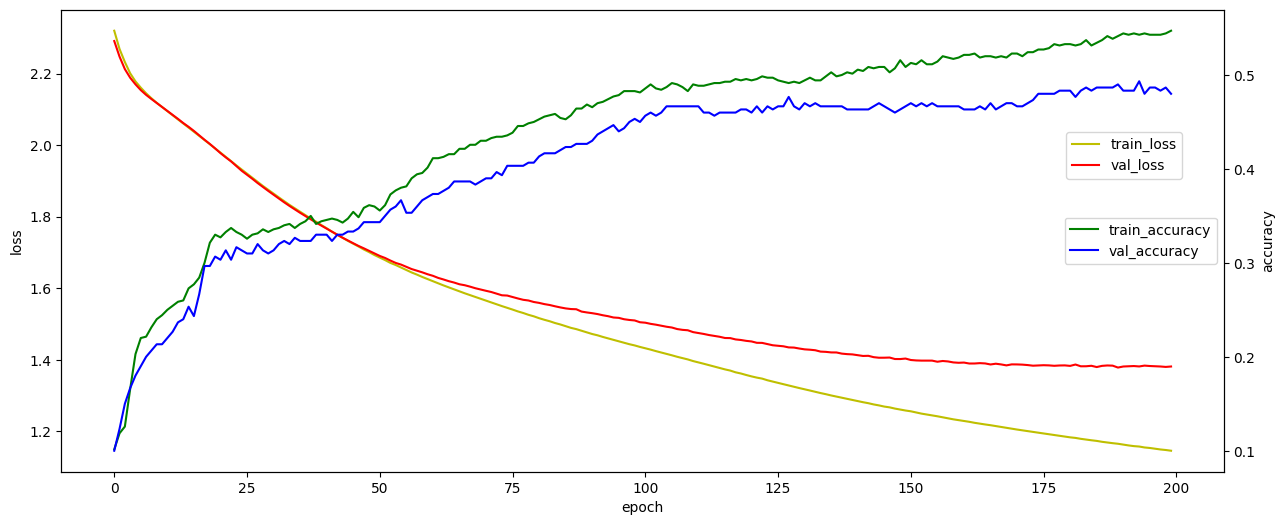

In [80]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [84]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.4263769388198853
accuracy : 0.4729999899864197


# 👍위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, 활성화함수를 relu계열, tahn, Dropout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [99]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
# val_idx   = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784->1024->512->128->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(BatchNormalization()) # 1024개 출력층을 배치 정규화
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=30, 
                verbose=2
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_34 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization_6 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dropout_6 (Dropout)         (None, 1024)              0         
                                                                 
 dense_35 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_7 (Batc  (None, 512)      

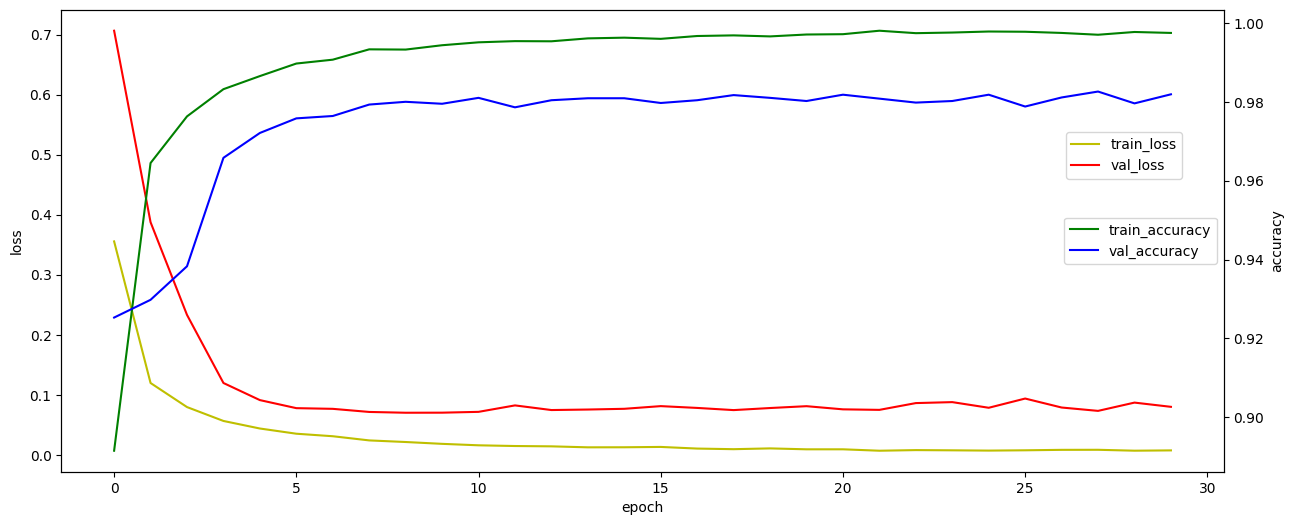

loss : 0.07805439829826355
accuracy : 0.9819999933242798


In [100]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [108]:
# 교차표
y_test # 실제값 
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [111]:
y_hat = model.predict(test_X).argmax(axis=1) # 예측값
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [112]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,971,1,0,0,1,1,3,1,1,1
1,0,1125,4,1,0,0,2,1,2,0
2,2,0,1013,1,1,0,2,7,6,0
3,3,0,3,987,0,4,0,7,5,1
4,0,0,0,1,962,0,6,2,0,11
5,2,0,0,6,1,871,7,1,1,3
6,5,2,0,0,3,4,943,0,1,0
7,1,4,5,2,2,0,0,1009,3,2
8,3,0,1,4,0,6,1,5,950,4


In [113]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 971,    1,    0,    0,    1,    1,    3,    1,    1,    1],
       [   0, 1125,    4,    1,    0,    0,    2,    1,    2,    0],
       [   2,    0, 1013,    1,    1,    0,    2,    7,    6,    0],
       [   3,    0,    3,  987,    0,    4,    0,    7,    5,    1],
       [   0,    0,    0,    1,  962,    0,    6,    2,    0,   11],
       [   2,    0,    0,    6,    1,  871,    7,    1,    1,    3],
       [   5,    2,    0,    0,    3,    4,  943,    0,    1,    0],
       [   1,    4,    5,    2,    2,    0,    0, 1009,    3,    2],
       [   3,    0,    1,    4,    0,    6,    1,    5,  950,    4],
       [   3,    2,    0,    3,    6,    2,    0,    3,    1,  989]],
      dtype=int64)

In [115]:
# 틀린갯수
accuracy = loss_metrics[1]
10000 - 10000 * accuracy

180.00006675720215

# ※ 콜백함수 1: 로그출력

In [4]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [5]:
%%time
# 특정 에포크마다 로그출력을 하도록 제한하는 callback 클래스
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        '1 epoch 수행 후 자동 실행되는 함수'
        self.epoch += 1
        if self.epoch%10==0: # 10에포크마다 로그출력
            print('epoch:{}, loss:{:.4f}, acc:{:.4f}, val_loss:{:.4f}, val_acc:{:.4f}'\
                  .format(self.epoch,
                         logs.get('loss', '-'),
                         logs.get('accuracy', '-'),
                         logs.get('val_loss', '-'),
                         logs.get('val_accuracy', '-')
                         )
                 )
            
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
customHistory = CustomHistory()
print(customHistory.epoch)
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=0,
                callbacks=[customHistory] 
                )

(700, 784) (700, 10) (300, 784) (300, 10) (10000, 784) (10000, 10)
0
epoch:10, loss:2.2261, acc:0.2029, val_loss:2.2443, val_acc:0.1600
epoch:20, loss:2.1598, acc:0.2357, val_loss:2.1897, val_acc:0.1733
epoch:30, loss:2.1105, acc:0.2414, val_loss:2.1470, val_acc:0.1800
epoch:40, loss:2.0717, acc:0.2443, val_loss:2.1157, val_acc:0.2000
epoch:50, loss:2.0390, acc:0.2486, val_loss:2.0886, val_acc:0.2100
epoch:60, loss:2.0100, acc:0.2529, val_loss:2.0649, val_acc:0.2300
epoch:70, loss:1.9833, acc:0.2614, val_loss:2.0447, val_acc:0.2500
epoch:80, loss:1.9585, acc:0.2614, val_loss:2.0260, val_acc:0.2433
epoch:90, loss:1.9353, acc:0.2800, val_loss:2.0080, val_acc:0.2600
epoch:100, loss:1.9133, acc:0.2857, val_loss:1.9920, val_acc:0.2567
epoch:110, loss:1.8922, acc:0.2971, val_loss:1.9768, val_acc:0.2633
epoch:120, loss:1.8722, acc:0.3071, val_loss:1.9628, val_acc:0.2667
epoch:130, loss:1.8533, acc:0.3114, val_loss:1.9497, val_acc:0.2767
epoch:140, loss:1.8352, acc:0.3114, val_loss:1.9375, val

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [7]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=3) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping] 
                )

Epoch 1/200
1/1 - 0s - loss: 2.3463 - accuracy: 0.0643 - val_loss: 2.3150 - val_accuracy: 0.0833 - 406ms/epoch - 406ms/step
Epoch 2/200
1/1 - 0s - loss: 2.3322 - accuracy: 0.0600 - val_loss: 2.3041 - val_accuracy: 0.0933 - 28ms/epoch - 28ms/step
Epoch 3/200
1/1 - 0s - loss: 2.3209 - accuracy: 0.0614 - val_loss: 2.2959 - val_accuracy: 0.1067 - 29ms/epoch - 29ms/step
Epoch 4/200
1/1 - 0s - loss: 2.3111 - accuracy: 0.0729 - val_loss: 2.2902 - val_accuracy: 0.1200 - 30ms/epoch - 30ms/step
Epoch 5/200
1/1 - 0s - loss: 2.3035 - accuracy: 0.0800 - val_loss: 2.2858 - val_accuracy: 0.1200 - 32ms/epoch - 32ms/step
Epoch 6/200
1/1 - 0s - loss: 2.2978 - accuracy: 0.0814 - val_loss: 2.2826 - val_accuracy: 0.1133 - 32ms/epoch - 32ms/step
Epoch 7/200
1/1 - 0s - loss: 2.2932 - accuracy: 0.0771 - val_loss: 2.2799 - val_accuracy: 0.1200 - 31ms/epoch - 31ms/step
CPU times: total: 734 ms
Wall time: 678 ms


# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_acc(va_loss, loss, acc)값이 좋을 때마다 모델을 자동 저장하는 콜백

In [8]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 자동 저장 콜백
import os
model_save_folder = 'model07/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist_{epoch:03d}_val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy', # 모니터할 지표(기본값은 val_loss)
                            save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                            mode = 'max', # 값이 커질수록 저장
                            verbose=1 
                            )

earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, checkpoint] 
                )

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.11667, saving model to model07\mnist_001_val0.1167.h5
1/1 - 0s - loss: 2.3367 - accuracy: 0.0929 - val_loss: 2.3308 - val_accuracy: 0.1167 - 426ms/epoch - 426ms/step
Epoch 2/200

Epoch 2: val_accuracy did not improve from 0.11667
1/1 - 0s - loss: 2.3216 - accuracy: 0.0943 - val_loss: 2.3164 - val_accuracy: 0.1167 - 26ms/epoch - 26ms/step
Epoch 3/200

Epoch 3: val_accuracy improved from 0.11667 to 0.12000, saving model to model07\mnist_003_val0.1200.h5
1/1 - 0s - loss: 2.3089 - accuracy: 0.0900 - val_loss: 2.3041 - val_accuracy: 0.1200 - 40ms/epoch - 40ms/step
Epoch 4/200

Epoch 4: val_accuracy improved from 0.12000 to 0.12333, saving model to model07\mnist_004_val0.1233.h5
1/1 - 0s - loss: 2.2978 - accuracy: 0.0986 - val_loss: 2.2923 - val_accuracy: 0.1233 - 40ms/epoch - 40ms/step
Epoch 5/200

Epoch 5: val_accuracy did not improve from 0.12333
1/1 - 0s - loss: 2.2880 - accuracy: 0.1086 - val_loss: 2.2811 - val_accuracy: 0.1233 

1/1 - 0s - loss: 2.0619 - accuracy: 0.2743 - val_loss: 2.0295 - val_accuracy: 0.3033 - 29ms/epoch - 29ms/step
Epoch 42/200

Epoch 42: val_accuracy did not improve from 0.30667
1/1 - 0s - loss: 2.0576 - accuracy: 0.2786 - val_loss: 2.0252 - val_accuracy: 0.3000 - 28ms/epoch - 28ms/step
Epoch 43/200

Epoch 43: val_accuracy did not improve from 0.30667
1/1 - 0s - loss: 2.0534 - accuracy: 0.2729 - val_loss: 2.0210 - val_accuracy: 0.3000 - 26ms/epoch - 26ms/step
Epoch 44/200

Epoch 44: val_accuracy did not improve from 0.30667
1/1 - 0s - loss: 2.0493 - accuracy: 0.2771 - val_loss: 2.0169 - val_accuracy: 0.3000 - 29ms/epoch - 29ms/step
Epoch 45/200

Epoch 45: val_accuracy did not improve from 0.30667
1/1 - 0s - loss: 2.0451 - accuracy: 0.2800 - val_loss: 2.0130 - val_accuracy: 0.3000 - 24ms/epoch - 24ms/step
Epoch 46/200

Epoch 46: val_accuracy did not improve from 0.30667
1/1 - 0s - loss: 2.0412 - accuracy: 0.2843 - val_loss: 2.0090 - val_accuracy: 0.3033 - 29ms/epoch - 29ms/step
Epoch 47/2

In [9]:
# 최종 학습 모델
model.evaluate(test_X, test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.0343 - accuracy: 0.2743


[2.034271001815796, 0.2743000090122223]

In [10]:
# 저장된 모델 중 최선의 모델
model2 = load_model('model07/mnist_038_val0.3067.h5')
model2.evaluate(test_X, test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.0738 - accuracy: 0.2640


[2.07378888130188, 0.2639999985694885]

# ※ 콜백함수 4 : ReduceLROnPlateau
- 성능이 정체될 때 학습률(learning_rate)을 낮춰서 더 세밀하게 최적점을 찾도록 도와주는 콜백

In [11]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             # optimizer=Adam(learning_rate=0.001)
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 성능 정체시 학습률 낮추는 콜백
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',
                              patience=2,
                              factor=0.5,
                              min_lr=1e-6)

earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, reduce_lr] 
                )

Epoch 1/200
1/1 - 0s - loss: 2.3573 - accuracy: 0.0786 - val_loss: 2.3569 - val_accuracy: 0.0533 - lr: 0.0010 - 401ms/epoch - 401ms/step
Epoch 2/200
1/1 - 0s - loss: 2.3421 - accuracy: 0.0800 - val_loss: 2.3435 - val_accuracy: 0.0400 - lr: 0.0010 - 25ms/epoch - 25ms/step
Epoch 3/200
1/1 - 0s - loss: 2.3295 - accuracy: 0.0743 - val_loss: 2.3316 - val_accuracy: 0.0367 - lr: 0.0010 - 28ms/epoch - 28ms/step
Epoch 4/200
1/1 - 0s - loss: 2.3197 - accuracy: 0.0657 - val_loss: 2.3263 - val_accuracy: 0.0467 - lr: 5.0000e-04 - 28ms/epoch - 28ms/step
Epoch 5/200
1/1 - 0s - loss: 2.3159 - accuracy: 0.0686 - val_loss: 2.3221 - val_accuracy: 0.0533 - lr: 5.0000e-04 - 28ms/epoch - 28ms/step
Epoch 6/200
1/1 - 0s - loss: 2.3125 - accuracy: 0.0643 - val_loss: 2.3203 - val_accuracy: 0.0567 - lr: 2.5000e-04 - 28ms/epoch - 28ms/step
Epoch 7/200
1/1 - 0s - loss: 2.3109 - accuracy: 0.0686 - val_loss: 2.3187 - val_accuracy: 0.0500 - lr: 2.5000e-04 - 27ms/epoch - 27ms/step
Epoch 8/200
1/1 - 0s - loss: 2.3095 -